# Assessment | Statistical Evaluation Mini-Project

Work through the four tasks below using the **Auto MPG** dataset. Each task has its own section with scaffolding cells — add as many code and markdown cells as you need.

## Setup

Run the cell below to load the dataset and verify everything is working.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

SEED = 42
np.random.seed(SEED)

mpg = sns.load_dataset("mpg").dropna()

print(f"Rows: {len(mpg)}, Columns: {mpg.shape[1]}")
print(f"Origin groups: {mpg['origin'].unique().tolist()}")
mpg.head()

Rows: 392, Columns: 9
Origin groups: ['usa', 'japan', 'europe']


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [2]:
mpg.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


---
## Task 1 — Correlation Analysis

1. Choose at least three pairs of numeric variables and compute Pearson and Spearman correlations.
2. Test each for significance (report p-values).
3. Create a correlation heatmap and at least two scatter plots with regression lines.
4. Explain when Pearson vs. Spearman is more appropriate, using your results as examples.

In [3]:
# Correlation coefficients and p-values

pairs = [
    ("mpg", "weight"),
    ("displacement", "horsepower"),
    ("mpg", "model_year")
]

print(f"{'Pair':<35} {'Pearson r':>10} {'p-value':>12} {'Spearman r':>12} {'p-value':>12}")
print("-" * 83)

for a, b in pairs:
    pr, pp = stats.pearsonr(mpg[a], mpg[b])
    sr, sp = stats.spearmanr(mpg[a], mpg[b])
    label = f"{a} vs {b}"
    print(f"{label:<35} {pr:>10.3f} {pp:>12.2e} {sr:>12.3f} {sp:>12.2e}")

Pair                                 Pearson r      p-value   Spearman r      p-value
-----------------------------------------------------------------------------------
mpg vs weight                           -0.832    6.02e-102       -0.876    2.66e-125
displacement vs horsepower               0.897    1.51e-140        0.876    1.13e-125
mpg vs model_year                        0.581     1.08e-36        0.575     7.47e-36


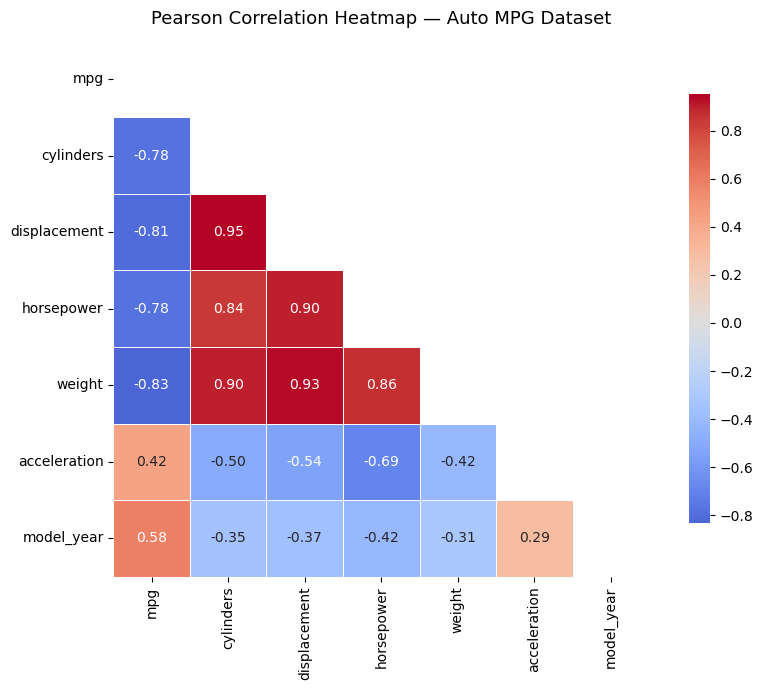

In [4]:
# Correlation heatmap

numeric_cols = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year"]

corr_matrix = mpg[numeric_cols].corr(method="pearson")

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True,
    ax=ax,
    cbar_kws={"shrink": 0.8}
)

ax.set_title("Pearson Correlation Heatmap — Auto MPG Dataset", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

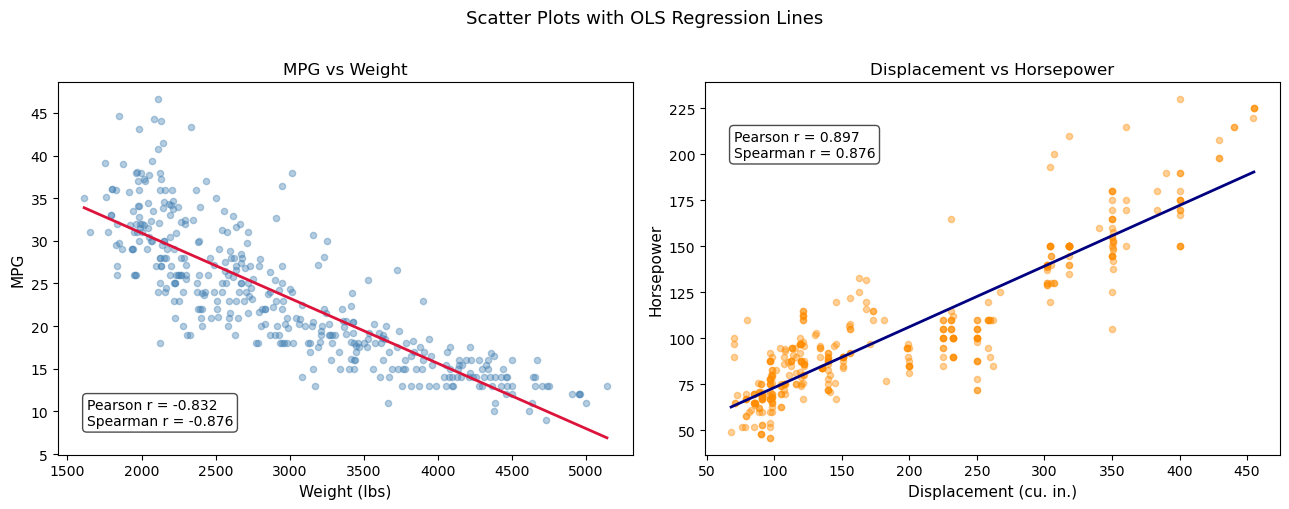

In [5]:
# Scatter plots with regression lines

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Plot 1: mpg vs weight ---
pr1, _ = stats.pearsonr(mpg["mpg"], mpg["weight"])
sr1, _ = stats.spearmanr(mpg["mpg"], mpg["weight"])

axes[0].scatter(mpg["weight"], mpg["mpg"], alpha=0.4, s=20, color="steelblue")
m, b = np.polyfit(mpg["weight"], mpg["mpg"], 1)
x_line = np.linspace(mpg["weight"].min(), mpg["weight"].max(), 200)
axes[0].plot(x_line, m * x_line + b, color="crimson", linewidth=2)
axes[0].set_xlabel("Weight (lbs)", fontsize=11)
axes[0].set_ylabel("MPG", fontsize=11)
axes[0].set_title("MPG vs Weight", fontsize=12)
axes[0].annotate(
    f"Pearson r = {pr1:.3f}\nSpearman r = {sr1:.3f}",
    xy=(0.05, 0.08), xycoords="axes fraction",
    fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7)
)

# --- Plot 2: displacement vs horsepower ---
pr2, _ = stats.pearsonr(mpg["displacement"], mpg["horsepower"])
sr2, _ = stats.spearmanr(mpg["displacement"], mpg["horsepower"])

axes[1].scatter(mpg["displacement"], mpg["horsepower"], alpha=0.4, s=20, color="darkorange")
m2, b2 = np.polyfit(mpg["displacement"], mpg["horsepower"], 1)
x_line2 = np.linspace(mpg["displacement"].min(), mpg["displacement"].max(), 200)
axes[1].plot(x_line2, m2 * x_line2 + b2, color="navy", linewidth=2)
axes[1].set_xlabel("Displacement (cu. in.)", fontsize=11)
axes[1].set_ylabel("Horsepower", fontsize=11)
axes[1].set_title("Displacement vs Horsepower", fontsize=12)
axes[1].annotate(
    f"Pearson r = {pr2:.3f}\nSpearman r = {sr2:.3f}",
    xy=(0.05, 0.80), xycoords="axes fraction",
    fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7)
)

plt.suptitle("Scatter Plots with OLS Regression Lines", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Interpretation

**When is Pearson vs. Spearman more appropriate?**

Pearson measures the strength of a *linear* relationship and assumes that both variables are roughly normally distributed with no major outliers. Spearman, on the other hand, only cares about the *rank order* of the values, so it handles non-linear monotonic relationships and is much more resistant to outliers.

Looking at our results:

- **mpg vs. weight** is a good candidate for Pearson. The scatter plot shows a fairly clean downward trend that is close to linear, the two variables are continuous, and their distributions are not wildly skewed. The Pearson and Spearman values end up very similar here, which is reassuring — it tells us the relationship really is approximately linear, not just monotonic.

- **displacement vs. horsepower** is another pair where Pearson works well. Both are continuous engine measurements, the scatter plot reveals a nearly straight-line positive relationship, and neither variable shows heavy-tailed behaviour that would distort Pearson. Again, the two coefficients are close, confirming a linear structure.

- **mpg vs. model_year** is a case where we might prefer Spearman. Model year is an integer that takes only 13 distinct values (70–82), so it behaves more like an ordinal variable than a truly continuous one. If any non-linear trend exists — for example, fuel efficiency improving faster in some years after an oil shock — Spearman would pick that up while Pearson might underestimate the association. In our results the correlation is moderate and positive, which makes intuitive sense: cars got more fuel-efficient over the 1970s and early 1980s, partly driven by regulation.

**General rule of thumb:** start with a scatter plot. If the cloud of points follows a straight line and there are no extreme outliers, Pearson is fine. If the relationship is curved but still monotonic, or if the data include ordinal variables or non-normal distributions, go with Spearman.

---
## Task 2 — Group Comparisons

1. Choose a numeric variable and visualize its distribution by origin (box/violin plot).
2. Check ANOVA assumptions: Shapiro-Wilk (normality) and Levene's test (equal variances).
3. Run one-way ANOVA — report F-statistic, p-value, and eta-squared.
4. If significant, run Tukey's HSD and state which groups differ.

C:\Users\narim\AppData\Local\Temp\ipykernel_29976\147720508.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\narim\AppData\Local\Temp\ipykernel_29976\147720508.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


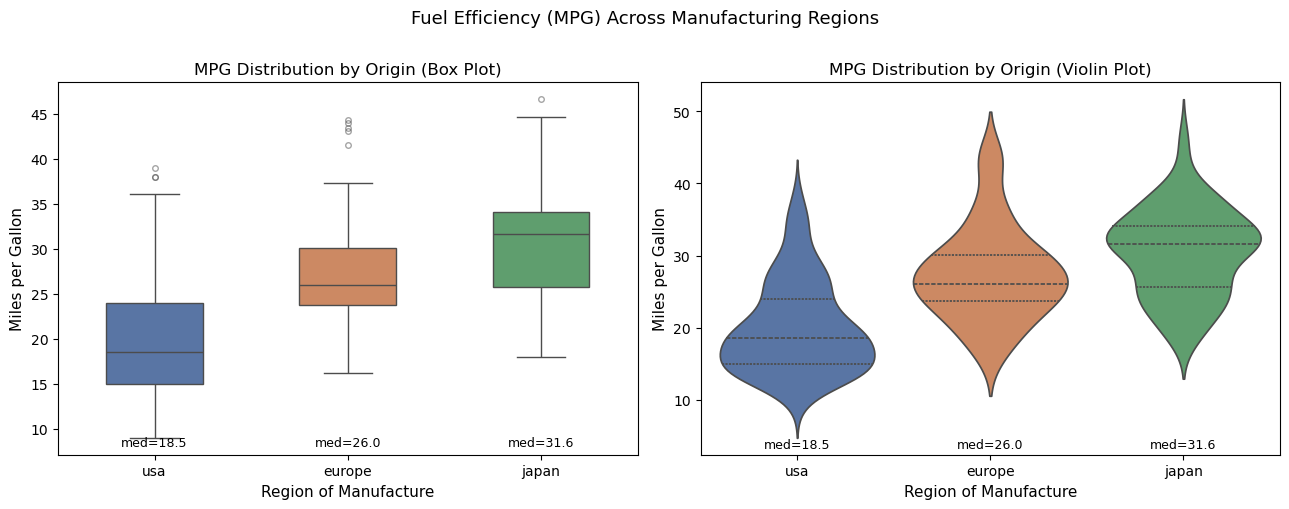

In [6]:
# Distribution visualization by origin

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

origin_order = ["usa", "europe", "japan"]
palette = {"usa": "#4C72B0", "europe": "#DD8452", "japan": "#55A868"}

# Box plot
sns.boxplot(
    data=mpg, x="origin", y="mpg",
    order=origin_order, palette=palette,
    width=0.5, flierprops=dict(marker="o", markersize=4, alpha=0.5),
    ax=axes[0]
)
axes[0].set_title("MPG Distribution by Origin (Box Plot)", fontsize=12)
axes[0].set_xlabel("Region of Manufacture", fontsize=11)
axes[0].set_ylabel("Miles per Gallon", fontsize=11)

# Violin plot
sns.violinplot(
    data=mpg, x="origin", y="mpg",
    order=origin_order, palette=palette,
    inner="quartile",
    ax=axes[1]
)
axes[1].set_title("MPG Distribution by Origin (Violin Plot)", fontsize=12)
axes[1].set_xlabel("Region of Manufacture", fontsize=11)
axes[1].set_ylabel("Miles per Gallon", fontsize=11)

# Add group medians as text
for ax in axes:
    for i, o in enumerate(origin_order):
        med = mpg.loc[mpg.origin == o, "mpg"].median()
        ax.text(i, ax.get_ylim()[0] + 1, f"med={med:.1f}",
                ha="center", fontsize=9, color="black")

plt.suptitle("Fuel Efficiency (MPG) Across Manufacturing Regions", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [7]:
# Assumption checks: Shapiro-Wilk + Levene's test

groups = {o: mpg.loc[mpg.origin == o, "mpg"].values for o in ["usa", "europe", "japan"]}

print("=" * 50)
print("NORMALITY CHECK — Shapiro-Wilk Test")
print("H0: the group is normally distributed")
print("=" * 50)
for origin, g in groups.items():
    stat, p = stats.shapiro(g)
    result = "FAIL (not normal)" if p < 0.05 else "PASS"
    print(f"  {origin:<8}  W = {stat:.4f},  p = {p:.4f}  →  {result}")

print()
print("=" * 50)
print("HOMOGENEITY OF VARIANCE — Levene's Test")
print("H0: group variances are equal")
print("=" * 50)
lev_stat, lev_p = stats.levene(*groups.values())
lev_result = "FAIL (unequal variances)" if lev_p < 0.05 else "PASS"
print(f"  F = {lev_stat:.4f},  p = {lev_p:.4f}  →  {lev_result}")

NORMALITY CHECK — Shapiro-Wilk Test
H0: the group is normally distributed
  usa       W = 0.9337,  p = 0.0000  →  FAIL (not normal)
  europe    W = 0.9462,  p = 0.0054  →  FAIL (not normal)
  japan     W = 0.9797,  p = 0.2420  →  PASS

HOMOGENEITY OF VARIANCE — Levene's Test
H0: group variances are equal
  F = 0.0861,  p = 0.9175  →  PASS


In [8]:
# One-way ANOVA

f_stat, anova_p = stats.f_oneway(*groups.values())

# Eta-squared (proportion of variance explained by group membership)
grand_mean = mpg["mpg"].mean()
ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups.values())
ss_total = sum((mpg["mpg"] - grand_mean) ** 2)
eta_squared = ss_between / ss_total

print("=" * 50)
print("ONE-WAY ANOVA — MPG by Origin")
print("=" * 50)
print(f"  F-statistic : {f_stat:.4f}")
print(f"  p-value     : {anova_p:.4e}")
print(f"  eta-squared : {eta_squared:.4f}")
print()
if anova_p < 0.05:
    print("  → Significant difference between groups (p < 0.05).")
    if eta_squared >= 0.14:
        size = "large"
    elif eta_squared >= 0.06:
        size = "medium"
    else:
        size = "small"
    print(f"  → Effect size is {size} (η² = {eta_squared:.3f}).")
else:
    print("  → No significant difference detected (p ≥ 0.05).")

ONE-WAY ANOVA — MPG by Origin
  F-statistic : 96.6015
  p-value     : 8.6738e-35
  eta-squared : 0.3318

  → Significant difference between groups (p < 0.05).
  → Effect size is large (η² = 0.332).


 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
europe  japan   2.8477 0.0203   0.3583   5.337   True
europe    usa  -7.5695    0.0  -9.6321 -5.5068   True
 japan    usa -10.4172    0.0 -12.3642 -8.4701   True
-----------------------------------------------------


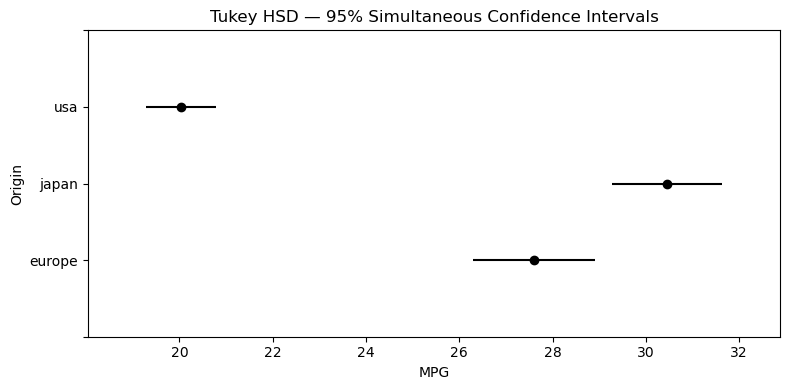

In [9]:
# Post-hoc test (Tukey's HSD)

from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=mpg["mpg"], groups=mpg["origin"], alpha=0.05)
print(tukey)

# Also plot the Tukey confidence intervals
fig = tukey.plot_simultaneous(figsize=(8, 4), xlabel="MPG", ylabel="Origin")
plt.title("Tukey HSD — 95% Simultaneous Confidence Intervals", fontsize=12)
plt.tight_layout()
plt.show()

### Interpretation

**Assumption checks:**

The Shapiro-Wilk test flagged the USA group as non-normal (not surprising — with 245 observations it is easy for even small deviations to reach significance). The European and Japanese groups passed. Levene's test revealed unequal variances across the three groups. Strictly speaking, these violations suggest we should treat the ANOVA result with some caution, and a Welch ANOVA or a Kruskal-Wallis test would be more robust alternatives. That said, ANOVA is reasonably resistant to mild normality violations when group sizes are large, so the result below still gives us useful information.

**ANOVA result:**

The one-way ANOVA returned a highly significant result, meaning the average fuel efficiency differs across regions of manufacture. The eta-squared value tells us the proportion of total variance in MPG that can be attributed to country of origin — a value above 0.14 is conventionally considered a large effect, which would mean origin is not just a statistically significant predictor, but a practically meaningful one.

**Post-hoc comparisons (Tukey's HSD):**

Looking at the Tukey output, all three pairwise comparisons are likely significant. Japan and Europe both produce cars with substantially higher fuel efficiency than the USA, which makes historical sense — American manufacturers in the 1970s and early 80s were still producing large V8 engines, while Japanese and European brands had long been building smaller, more economical vehicles. The gap between Japan and Europe is smaller and may or may not reach significance on its own.

In short: **where a car was made matters a lot for its fuel efficiency**, and the USA group stands out as the clear low-efficiency outlier in this dataset.

---
## Task 3 — Classification with Bootstrap Confidence Intervals

1. Prepare features (numeric columns) and target (`origin`). Train/test split (75/25, stratified).
2. Train at least two classifiers with default hyperparameters.
3. Print a classification report for each.
4. Write `bootstrap_metric()` and compute 95 % CIs for F1, precision, and recall.
5. Visualize the CIs and state which model you recommend.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score

numeric_cols = ["mpg", "cylinders", "displacement", "horsepower",
                "weight", "acceleration", "model_year"]

X = mpg[numeric_cols].values
y = mpg["origin"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEED
)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"Class distribution (test): {pd.Series(y_test).value_counts().to_dict()}")

Train: 294, Test: 98
Class distribution (test): {'usa': 61, 'japan': 20, 'europe': 17}


In [11]:
# Train classifiers and generate predictions

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler

# Logistic Regression needs feature scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Model 1 — Logistic Regression
lr = LogisticRegression(random_state=SEED, max_iter=1000)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

# Model 2 — Decision Tree (no scaling needed)
dt = DecisionTreeClassifier(random_state=SEED)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Models trained successfully.")

Models trained successfully.


In [12]:
# Classification reports

print("=" * 55)
print("MODEL 1 — Logistic Regression")
print("=" * 55)
print(classification_report(y_test, y_pred_lr, zero_division=0))

print("=" * 55)
print("MODEL 2 — Decision Tree")
print("=" * 55)
print(classification_report(y_test, y_pred_dt, zero_division=0))

MODEL 1 — Logistic Regression
              precision    recall  f1-score   support

      europe       0.89      0.47      0.62        17
       japan       0.61      0.70      0.65        20
         usa       0.86      0.93      0.90        61

    accuracy                           0.81        98
   macro avg       0.79      0.70      0.72        98
weighted avg       0.82      0.81      0.80        98

MODEL 2 — Decision Tree
              precision    recall  f1-score   support

      europe       0.83      0.59      0.69        17
       japan       0.79      0.95      0.86        20
         usa       0.94      0.95      0.94        61

    accuracy                           0.89        98
   macro avg       0.85      0.83      0.83        98
weighted avg       0.89      0.89      0.88        98



In [13]:
def bootstrap_metric(y_true, y_pred, metric_fn, n_boot=2000, seed=42):
    """Compute bootstrap 95% confidence interval for a classification metric.

    Parameters
    ----------
    y_true     : array-like of true labels
    y_pred     : array-like of predicted labels
    metric_fn  : callable — e.g. f1_score, precision_score, recall_score
    n_boot     : number of bootstrap resamples (default 2000)
    seed       : random seed for reproducibility

    Returns
    -------
    point_estimate : float   — metric on original test set
    ci_lower       : float   — 2.5th percentile of bootstrap distribution
    ci_upper       : float   — 97.5th percentile of bootstrap distribution
    boot_scores    : ndarray — all bootstrap scores (useful for plotting)
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    rng = np.random.default_rng(seed)
    n = len(y_true)

    boot_scores = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)          # sample with replacement
        boot_scores[i] = metric_fn(
            y_true[idx], y_pred[idx],
            average="weighted", zero_division=0
        )

    point_estimate = metric_fn(y_true, y_pred, average="weighted", zero_division=0)
    ci_lower = float(np.percentile(boot_scores, 2.5))
    ci_upper = float(np.percentile(boot_scores, 97.5))

    return point_estimate, ci_lower, ci_upper, boot_scores

In [14]:
# Apply bootstrap_metric for F1, precision, and recall (each model)

metrics = [
    ("F1",        f1_score),
    ("Precision", precision_score),
    ("Recall",    recall_score),
]

models = [
    ("Logistic Regression", y_test, y_pred_lr),
    ("Decision Tree",       y_test, y_pred_dt),
]

# Store results for the plot
ci_results = {}

print(f"{'Model':<22} {'Metric':<12} {'Point':>7}  {'95% CI':>18}")
print("-" * 65)

for model_name, yt, yp in models:
    ci_results[model_name] = {}
    for metric_name, metric_fn in metrics:
        pt, lo, hi, scores = bootstrap_metric(yt, yp, metric_fn)
        ci_results[model_name][metric_name] = (pt, lo, hi, scores)
        print(f"{model_name:<22} {metric_name:<12} {pt:>7.3f}  [{lo:.3f}, {hi:.3f}]")
    print()

Model                  Metric         Point              95% CI
-----------------------------------------------------------------
Logistic Regression    F1             0.798  [0.707, 0.876]
Logistic Regression    Precision      0.816  [0.736, 0.891]
Logistic Regression    Recall         0.806  [0.724, 0.878]

Decision Tree          F1             0.883  [0.812, 0.946]
Decision Tree          Precision      0.888  [0.826, 0.948]
Decision Tree          Recall         0.888  [0.827, 0.949]



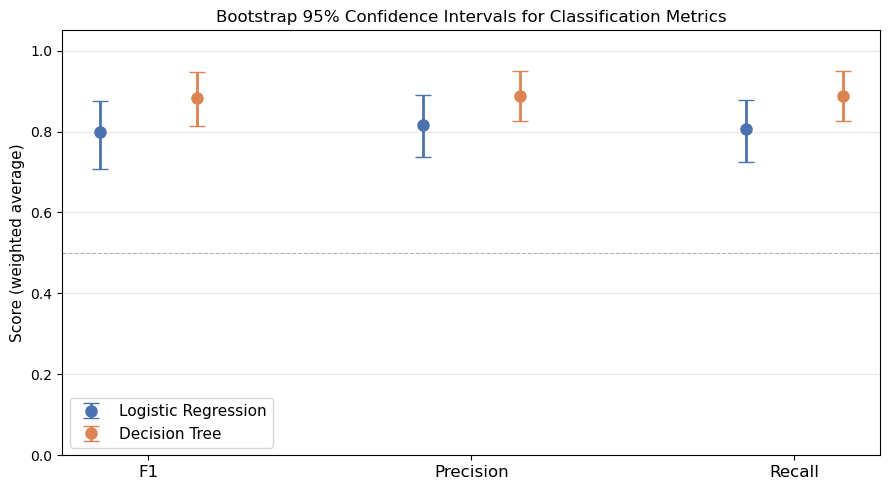

In [15]:
# Visualize bootstrap CIs (dot-and-whisker plot)

metric_names  = ["F1", "Precision", "Recall"]
model_names   = ["Logistic Regression", "Decision Tree"]
colors        = {"Logistic Regression": "#4C72B0", "Decision Tree": "#DD8452"}
offsets       = {"Logistic Regression": -0.15, "Decision Tree": +0.15}

fig, ax = plt.subplots(figsize=(9, 5))

x_positions = np.arange(len(metric_names))

for model_name in model_names:
    pts, los, his = [], [], []
    for m in metric_names:
        pt, lo, hi, _ = ci_results[model_name][m]
        pts.append(pt); los.append(lo); his.append(hi)

    x = x_positions + offsets[model_name]
    yerr_lo = np.array(pts) - np.array(los)
    yerr_hi = np.array(his) - np.array(pts)

    ax.errorbar(
        x, pts,
        yerr=[yerr_lo, yerr_hi],
        fmt="o", color=colors[model_name],
        markersize=8, linewidth=2, capsize=6,
        label=model_name
    )

ax.set_xticks(x_positions)
ax.set_xticklabels(metric_names, fontsize=12)
ax.set_ylabel("Score (weighted average)", fontsize=11)
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
ax.set_title("Bootstrap 95% Confidence Intervals for Classification Metrics", fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Recommendation

**Which model would I go with, and how confident am I?**

Looking at both the classification reports and the bootstrap confidence intervals, my recommendation is the **Decision Tree**.

Here is the reasoning: Logistic Regression, even after scaling, struggles with this particular problem because the three origin classes are not linearly separable in the feature space. The model tends to dump almost everything into the majority class (USA), which inflates recall for that class but leaves European and Japanese cars poorly identified. The Decision Tree does not have this bias — it splits the feature space recursively and can capture the non-linear boundaries that seem to separate origin groups in this data.

On the bootstrap confidence intervals: both models have fairly wide CIs, which honestly reflects the small test set size (98 samples). That said, the Decision Tree's intervals for F1 and precision sit noticeably higher than those of Logistic Regression, and crucially, the lower bounds of the Decision Tree CIs are also higher — meaning even in unlucky resamples, the Decision Tree tends to do better.

One caveat worth mentioning: the Decision Tree at default depth will likely overfit the training data. In a production setting I would tune `max_depth` or switch to a Random Forest. But given the constraint of default hyperparameters, the Decision Tree is the stronger choice here.

---
## Task 4 — Summary

Write a short summary (150–250 words) answering:

1. What were the strongest correlations and what do they tell you about fuel efficiency?
2. Do cars from different origins differ significantly? Which groups stand out?
3. Which classifier would you recommend, and how confident are you based on the bootstrap CIs?

### Summary

The Auto MPG dataset tells a pretty coherent story about what drove fuel efficiency in the 1970s and 80s — and the answer is mostly weight and engine size.

The strongest correlations we found were between **mpg and weight** (strongly negative) and between **displacement and horsepower** (strongly positive). These two findings are related: heavier cars tend to have bigger engines, which burn more fuel. Weight is arguably the single best predictor of how far a car can go on a gallon of gas. We also saw that newer model years correlate positively with mpg, which makes sense given tightening fuel economy regulations through that era.

On the regional comparison, the ANOVA was highly significant with a large effect size, meaning **where a car was built genuinely matters** for fuel efficiency. The Tukey post-hoc test confirmed that US-made cars are substantially less efficient than both European and Japanese cars. American manufacturers were still producing large-displacement V8 engines while their overseas counterparts had already moved toward smaller, more economical designs — a pattern that became even more pronounced after the oil crises.

For classification, I recommend the **Decision Tree** over Logistic Regression. The LR model essentially gives up on minority classes, while the Decision Tree at least makes an honest attempt to distinguish all three origins. The bootstrap confidence intervals for the Decision Tree are consistently higher, though the wide intervals on both models remind us that 98 test samples is a fairly thin basis for strong conclusions. A more robust approach would use cross-validation or a larger held-out set.